# Research Notebook
This notebook is an exact cell‑structured version of the provided Python research script.
No computational logic has been changed. Cells are only separated for clarity and execution.

In [2]:
import matplotlib.pyplot as plt
import os

# Directory to save PDF figures
PDF_DIR = "figures_pdf"
# Create the directory if it doesn't exist
if not os.path.exists(PDF_DIR):
    os.makedirs(PDF_DIR)

# Store the original plt.show function for later use
_old_show = plt.show

# Counter for automatic naming of figures
_fig_id = 0
def new_show(*args, **kwargs):
        """
    Replacement for plt.show that saves the current figure as a PDF
    before displaying it.
    """
    global _fig_id
    # Build filename with incremental number
    
    filename = os.path.join(PDF_DIR, f"figure_{_fig_id}.pdf")
    # Save the current figure with tight bounding box
    plt.savefig(filename, bbox_inches='tight')
    print("Saved:", filename)
      # Increment counter for next figure
    _fig_id += 1
    # Call the original plt.show to actually display the figure
    return _old_show(*args, **kwargs)

# Override plt.show with our custom version
plt.show = new_show

IndentationError: unindent does not match any outer indentation level (<string>, line 20)

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter


In [33]:
# ============================================================
# Global plotting style

In [ ]:
# ============================================================
# Update matplotlib's global parameters for consistent publication-ready plots
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

# Color dictionary for consistent coloring across plots
COL = {
    "base": "#1f77b4",
    "tr":   "#d62728",
    "aux":  "#2ca02c",
    "res":  "#9467bd",
    "shade":"#f2c14e",
    "dark": "#222222",
}

def beautify_linear_ax(ax):
    """
    Apply a consistent aesthetic to a linear-scale axis:
    - Light grid lines
    - Auto minor ticks
    - Ticks on both top and right spines
    """
    ax.grid(True, alpha=0.22, lw=0.7)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which="both", top=True, right=True)

def beautify_log_ax(ax):
    """
    Apply a consistent aesthetic to a log-scale axis:
    - Grid lines for major and minor ticks
    - Custom minor tick locator for log scale
    - Disable minor tick labels to avoid clutter
    - Ticks on both top and right spines
    """
    ax.grid(True, which="major", alpha=0.22, lw=0.7)
    ax.grid(True, which="minor", alpha=0.10, lw=0.4)
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(which="both", top=True, right=True)


In [35]:
# ============================================================
# Constants

In [36]:
# ============================================================
G = 6.67430e-11
c = 299792458.0
MSUN = 1.98847e30
PC = 3.085677581491367e16
GPC = 1e9 * PC
YEAR = 31557600.0

# surrogate LISA arm transfer scale
L_LISA = 2.5e9
f_star = c / (2.0 * np.pi * L_LISA)


In [37]:
# ============================================================
# Parameters

In [38]:
# ============================================================
pars = {
    # source
    "M_BH_Msun": 2.0e5,
    "mu_NS_Msun": 1.4,
    "ahat": 0.90,
    "distance_Gpc": 1.0,
    "iota": 0.50,
    "lambda_ecl": 1.10,
    "beta_ecl": 0.35,
    "psi_pol": 0.60,

    # observation
    "Tobs_yr": 0.35,
    "dt": 10.0,

    # transition model
    "transition_model": "mixed",   # "step" or "mixed"
    "Lambda_H": 450.0,
    "Lambda_Q": 120.0,
    "vc": 0.24,
    "vh": 0.34,
    "vq": 0.40,

    # tidal-response sector
    "kappa0": 0.03,
    "h2": 0.10,
    "h3s": 0.02,
    "h4": 0.00,

    # numerical grid
    "Nv": 70000,
    "v_floor": 0.03,
    "v_end_factor": 0.985,

    # flux-root safety
    "flux_root_safety": 0.98,
    "flux_scan_points": 4000,

    # effective multimode surrogate
    "modes": [(2, 1.0), (3, 0.40), (4, 0.20), (5, 0.10), (6, 0.05)],

    # stability floor for denominator 1 + Lambda*H
    "den_floor": 0.15,

    # plotting / output
    "show_last_days": 0.02,
    "save_figure": True,
    "figure_name": "gw_transition_fluxsafe.png",
    "save_data": True,
    "data_prefix": "gw_transition_fluxsafe",
}


In [39]:
# ============================================================
# Kerr circular orbit functions

In [ ]:
# Kerr EMRI auxiliary functions (geometrized units: G = c = 1)

def r_isco_signed(ahat):
    """
    Compute the innermost stable circular orbit (ISCO) radius for a Kerr black hole.
    Returns the signed ISCO radius: positive for prograde orbits (spin > 0),
    negative for retrograde orbits (spin < 0) with appropriate sign.
    """
    chi = abs(ahat)                     # magnitude of spin
    sigma = 1.0 if ahat >= 0 else -1.0  # sign: +1 for prograde, -1 for retrograde
    # z1 and z2 are standard Kerr ISCO expressions (Bardeen et al. 1972)
    z1 = 1.0+(1.0-chi**2)**(1.0/3.0) * ((1.0 + chi)**(1.0/3.0) + (1.0 - chi)**(1.0/3.0))
    z2 = np.sqrt(3.0 * chi**2 + z1**2)
    return 3.0+z2-sigma*np.sqrt((3.0-z1)*(3.0+z1+2.0*z2))

def v_isco(ahat):
    """
    Orbital velocity at ISCO, defined as v = (MΩ)^{1/3}, where Ω is the orbital frequency.
    """
    risco = r_isco_signed(ahat)         # ISCO radius in units of M
    return (1.0/(risco**1.5+ahat))**(1.0/3.0)

def u_of_v(v, ahat):
    """
    Convert the velocity parameter v = (MΩ)^{1/3} to u = (MΩ)^{2/3} / (1 - ahat v^3)^{2/3}.
    This is the dimensionless 'u' often used in the energy function.
    """
    return v**2/(1.0-ahat*v**3)**(2.0/3.0)

def dE_tilde_dv(v, ahat):
    """
    Derivative of the specific energy (scaled by μ) with respect to velocity v.
    Used to compute the adiabatic inspiral evolution.
    """
    A = 1.0 - ahat * v**3
    u = v**2 / A**(2.0/3.0)
    sqrtu = np.sqrt(u)

    # Terms from the geodesic energy expression
    B = 1.0-3.0*u + 2.0*ahat*u*sqrtu
    D = np.sqrt(B)
    N = 1.0-2.0*u+ahat*u*sqrtu

    # Derivatives for chain rule
    dN_du = -2.0+1.5*ahat*sqrtu
    dB_du = -3.0+3.0*ahat*sqrtu

    dE_du = (dN_du*D-N*0.5*dB_du/D)/B
    du_dv = 2.0*v/A**(5.0/3.0)
    return dE_du*du_dv

def Fhat_PP(v, ahat):
    """
    Post-Newtonian gravitational wave flux (energy loss rate) scaled by μ².
    Includes terms up to 2.5 PN order with spin-orbit and spin-spin contributions.
    """
    return (32.0/5.0) * v**10 * (
        1.0
        - (1247.0/336.0)*v**2                # 1 PN
        + (4.0*np.pi - 11.0*ahat/4.0)*v**3   # 1.5 PN (spin-orbit)
        + (-44711.0/9072.0 + 33.0*ahat**2/16.0)*v**4   # 2 PN (including spin-spin)
        + (-8191.0*np.pi/672.0 - 59.0*ahat/16.0)*v**5   # 2.5 PN
    )

In [41]:
# ============================================================
# Transition model

In [ ]:
# Waveform transition functions for hybrid EMRI waveforms

def smoothstep(y):
    """
    Smoothstep function (cubic Hermite interpolation).
    Maps y in [0,1] to a smooth S-shaped curve:
        - 0 for y <= 0
        - 3y^2 - 2y^3 for 0 < y < 1
        - 1 for y >= 1
    Used to blend between two waveforms or parameters.
    """
    y = np.asarray(y)
    out = np.zeros_like(y)
    m1 = (y > 0.0) & (y < 1.0)
    m2 = y >= 1.0
    out[m1] = 3.0 * y[m1]**2 - 2.0 * y[m1]**3
    out[m2] = 1.0
    return out

def Lambda_transition(v, p):
    """
    Compute the transition blending factor Lambda as a function of velocity.
    v is the velocity parameter v = (MΩ)^{1/3}.
    p is a dictionary of parameters containing:
        - 'transition_model': either 'step' or 'mixed'
        - 'vc': transition velocity for step model
        - 'vh', 'vq': start and end velocities for mixed model
        - 'Lambda_H', 'Lambda_Q': Lambda values for high (H) and low (Q) regimes
    Returns Lambda(v) which smoothly interpolates between Lambda_H and Lambda_Q.
    """
    LH = p["Lambda_H"]
    LQ = p["Lambda_Q"]

    if p["transition_model"] == "step":
        # Step function: jump at v = vc
        return np.where(v < p["vc"], LH, LQ)
    elif p["transition_model"] == "mixed":
        # Smooth transition using smoothstep over the interval [vh, vq]
        y = (v - p["vh"]) / (p["vq"] - p["vh"])
        return LH + (LQ - LH) * smoothstep(y)
    else:
        raise ValueError("transition_model must be 'step' or 'mixed'")

def H_tidal(v, ahat, p):
    """
    Tidal heating contribution (energy absorption by the black hole) as a function of velocity.
    Following the post-Newtonian expansion for tidal heating in Kerr.
    p contains the coefficients: kappa0, h2, h3s, h4.
    """
    return p["kappa0"] * v**10 * (
        1.0
        + p["h2"] * v**2
        + p["h3s"] * ahat * v**3
        + p["h4"] * v**4
    )

def phase_kernel_K(v, ahat, q):
    """
    Kernel for the phase evolution in the frequency domain.
    Defined as K(v) = - (v^3 / q) * (dE/dv) / Fhat_PP(v),
    where:
        - v is the velocity parameter
        - ahat is the Kerr spin
        - q = μ/M is the mass ratio
        - dE/dv is from dE_tilde_dv (specific energy derivative)
        - Fhat_PP is the post-Newtonian flux
    This kernel appears in the stationary phase approximation for the Fourier phase.
    """
    return -(v**3 / q) * dE_tilde_dv(v, ahat) / Fhat_PP(v, ahat)

def f22_of_v(v, p):
    """
    Convert the velocity parameter v = (MΩ)^{1/3} to the gravitational wave frequency
    of the dominant (2,2) mode, assuming the quadrupole relation: f = v^3 / (π M).
    p must contain 'M_BH_Msun' (central BH mass in solar masses).
    Returns frequency in Hz.
    """
    M_sec = G * (p["M_BH_Msun"] * MSUN) / c**3  # mass in seconds (geometrized units)
    return v**3 / (np.pi * M_sec)

def transition_band_in_frequency(p):
    """
    Determine the frequency band over which the waveform transition occurs.
    Returns a tuple: (model_type, f_low, f_high) where f_low and f_high are
    the frequencies (in Hz) corresponding to the start and end of the transition.
    For step model, both are the same (the step frequency).
    For mixed model, returns the range [fh, fq].
    """
    if p["transition_model"] == "step":
        fc = f22_of_v(p["vc"], p)
        return ("step", fc, fc)
    elif p["transition_model"] == "mixed":
        fh = f22_of_v(p["vh"], p)
        fq = f22_of_v(p["vq"], p)
        return ("mixed", fh, fq)
    return (None, None, None)

In [3]:
# ============================================================
# Flux-root safety

In [ ]:
# ============================================================
# Flux root finding and termination condition utilities
def find_flux_root(ahat, p):
    """
    Find the first positive root of Fhat_PP(v, ahat) within the inspiral domain.
    Returns None if no sign change is found.
    
    This function scans the velocity range and uses Brent's method to precisely
    find the root where the flux becomes zero (i.e., the adiabatic inspiral would stall).
    Returns:
        v_root: velocity of the root if found, otherwise None.
    """
    # Define the search range in velocity
    vmin = max(p["v_floor"], 1e-4)                     # lower bound, avoid v=0
    vmax = min(0.999 * v_isco(ahat), 0.95)            # upper bound, stay below ISCO

    # Perform a coarse scan to locate sign changes
    vs = np.linspace(vmin, vmax, p["flux_scan_points"])
    Fs = Fhat_PP(vs, ahat)

    for i in range(len(vs) - 1):
        # Skip NaN values
        if np.isnan(Fs[i]) or np.isnan(Fs[i+1]):
            continue
        # Exact zero at grid point
        if Fs[i] == 0.0:
            return vs[i]
        # Sign change detected
        if Fs[i] * Fs[i+1] < 0.0:
            # Use Brent's method for precise root
            return brentq(lambda x: Fhat_PP(x, ahat), vs[i], vs[i+1])

    # No root found in the scanned range
    return None

def choose_v_end(p):
    """
    Determine the terminal velocity v_end for the inspiral evolution.
    The termination can be due to either:
        - reaching ISCO (v_end = v_isco * v_end_factor)
        - hitting a flux root before ISCO (v_end = safety_factor * v_root)
    Returns a tuple:
        v_end (float): chosen terminal velocity
        v_root (float or None): the flux root if found, otherwise None
        reason (str): description of the termination cause
    """
    ahat = p["ahat"]
    # Nominal ISCO termination velocity
    v_end_nominal = p["v_end_factor"] * v_isco(ahat)

    # Search for a flux zero
    v_root = find_flux_root(ahat, p)

    if v_root is None:
        # No flux root – terminate at ISCO
        return v_end_nominal, None, "ISCO-limited"

    # Flux root exists – use a safety margin to stop before it
    v_safe = p["flux_root_safety"] * v_root
    v_end = min(v_end_nominal, v_safe)

    if v_end < v_end_nominal:
        # Root is encountered before ISCO, so we are flux-root-limited
        return v_end, v_root, "flux-root-limited"
    else:
        # Root is beyond ISCO, so we stop at ISCO anyway
        return v_end, v_root, "ISCO-limited"

In [45]:
# ============================================================
# Inspiral construction

In [ ]:
# ============================================================
# Waveform branch construction and time-domain interpolation

def check_denominator_stability(v, Lambda_v, ahat, p, label="branch"):
    """
    Check the stability of the denominator (1 + Lambda * H_tidal) in the
    phase evolution equation. The denominator must remain positive throughout
    the inspiral; this function raises an error if it falls below a threshold.
    Returns the denominator array for further use.
    """
    den = 1.0 + Lambda_v * H_tidal(v, ahat, p)
    dmin = np.min(den)
    idx = np.argmin(den)
    if dmin <= p["den_floor"]:
        f_bad = f22_of_v(v[idx], p)
        raise ValueError(
            f"[{label}] denominator too small: min(1+Lambda*H)={dmin:.6e} "
            f"at v={v[idx]:.6f}, f22={f_bad:.6e} Hz."
        )
    return den

def build_common_grid(p):
    """
    Build the common velocity grid for the baseline and transition branches.
    Determines the termination velocity v_end, the flux root (if any), and the
    reason for termination. Returns the full velocity array from v_floor to v_end,
    along with metadata.
    """
    v_end, v_root, cutoff_reason = choose_v_end(p)
    v = np.linspace(p["v_floor"], v_end, p["Nv"])
    return v, v_end, v_root, cutoff_reason

def build_branch(v, Lambda_v, p, label="branch"):
    """
    Construct a full waveform branch (baseline or transition) by solving the
    adiabatic inspiral equations. The input includes the velocity grid v and
    the transition blending factor Lambda_v (for the transition branch, this is
    a function of v; for the baseline branch, it is a constant).
    Returns a dictionary containing all derived quantities (time, phase, frequency)
    over the full grid and the truncated segment corresponding to the observation
    time Tobs.
    """
    M = p["M_BH_Msun"]
    mu = p["mu_NS_Msun"]
    ahat = p["ahat"]
    q = mu / M
    M_sec = G * (M * MSUN) / c**3        # central mass in seconds (geometrized units)

    # Check denominator positivity
    den = check_denominator_stability(v, Lambda_v, ahat, p, label=label)

    # Flux and phase evolution kernel
    flux = Fhat_PP(v, ahat)
    if np.any(flux <= 0.0):
        idx = np.where(flux <= 0.0)[0][0]
        raise ValueError(
            f"[{label}] flux became non-positive at v={v[idx]:.6f}, "
            f"f22={f22_of_v(v[idx], p):.6e} Hz. Increase flux-root safety."
        )

    K = phase_kernel_K(v, ahat, q)
    dphi_dv = K / den                     # dϕ/dv
    dt_dv = M_sec * dphi_dv / v**3        # dt/dv

    if np.any(dt_dv <= 0.0):
        idx = np.where(dt_dv <= 0.0)[0][0]
        raise ValueError(
            f"[{label}] dt/dv became non-positive at v={v[idx]:.6f}, "
            f"f22={f22_of_v(v[idx], p):.6e} Hz."
        )

    # Full time from the lowest velocity (v_floor) to v_end
    t_from_lowv = cumulative_trapezoid(dt_dv, v, initial=0.0)
    time_to_end = t_from_lowv[-1] - t_from_lowv

    # Observation time from parameters
    Tobs = p["Tobs_yr"] * YEAR
    if Tobs >= time_to_end[0]:
        raise ValueError(
            f"[{label}] Tobs too long for chosen v_floor. "
            f"Reduce Tobs_yr or decrease v_floor."
        )

    # Find the starting velocity such that the segment length equals Tobs
    # (time_to_end decreases with increasing v, so we interpolate reversed)
    v_start = np.interp(Tobs, time_to_end[::-1], v[::-1])
    mask = v >= v_start

    # Segment data
    v_seg = v[mask]
    Lambda_seg = Lambda_v[mask]
    den_seg = den[mask]
    dphi_dv_seg = dphi_dv[mask]
    dt_dv_seg = dt_dv[mask]

    # Time and orbital phase over the segment (starting from zero)
    t_seg = cumulative_trapezoid(dt_dv_seg, v_seg, initial=0.0)
    phi_orb_seg = cumulative_trapezoid(dphi_dv_seg, v_seg, initial=0.0)

    return {
        "label": label,
        "v_full": v,
        "Lambda_full": Lambda_v,
        "den_full": den,
        "v_seg": v_seg,
        "Lambda_seg": Lambda_seg,
        "den_seg": den_seg,
        "t_seg": t_seg,
        "phi_orb_seg": phi_orb_seg,
        "f22_seg": f22_of_v(v_seg, p),
        "f22_full": f22_of_v(v, p),
    }

def build_same_frequency_dephasing(base, tr, p, Nv_sf=4000):
    """
    Compute the dephasing between the baseline and transition waveforms
    as a function of the gravitational wave frequency f22. The dephasing
    is defined as 2 * (ϕ_tr - ϕ_base) at the same instantaneous frequency.
    Both branches must have overlapping velocity (frequency) ranges.
    Returns:
        v_sf: velocity grid of the common frequency range
        f22_sf: corresponding f22 frequencies
        dphi_sf: dephasing (radians) on that grid
    """
    # Common velocity range
    vmin = max(base["v_seg"][0], tr["v_seg"][0])
    vmax = min(base["v_seg"][-1], tr["v_seg"][-1])
    if vmin >= vmax:
        raise ValueError("No overlapping v-domain for same-frequency comparison.")

    # Interpolate phases onto a common fine grid
    v_sf = np.linspace(vmin, vmax, Nv_sf)
    phi_b_fun = interp1d(base["v_seg"], base["phi_orb_seg"], kind="linear")
    phi_t_fun = interp1d(tr["v_seg"], tr["phi_orb_seg"], kind="linear")

    # Remove arbitrary phase offsets at the common start
    phi_b0 = float(phi_b_fun(vmin))
    phi_t0 = float(phi_t_fun(vmin))
    phi_b_sf = phi_b_fun(v_sf) - phi_b0
    phi_t_sf = phi_t_fun(v_sf) - phi_t0

    f22_sf = f22_of_v(v_sf, p)
    dphi_sf = 2.0 * (phi_t_sf - phi_b_sf)   # dephasing in gravitational-wave phase

    return v_sf, f22_sf, dphi_sf

def build_uniform_time_series(branch, p):
    """
    Convert a waveform branch from the natural v-grid to a uniform time grid
    with spacing dt. This is used to generate time-domain waveforms for FFT.
    Returns a dictionary with:
        t: uniform time array (starting from 0)
        v_t: velocity at each time
        phi_t: orbital phase
        Lambda_t: transition blending factor
        f22_t: gravitational wave frequency
    """
    Tobs = p["Tobs_yr"] * YEAR
    n = int(np.floor(Tobs / p["dt"])) + 1
    t = np.arange(n) * p["dt"]

    # Interpolators from t_seg to uniform grid
    v_of_t = interp1d(
        branch["t_seg"], branch["v_seg"], kind="linear",
        bounds_error=False,
        fill_value=(branch["v_seg"][0], branch["v_seg"][-1])
    )
    phi_of_t = interp1d(
        branch["t_seg"], branch["phi_orb_seg"], kind="linear",
        bounds_error=False,
        fill_value=(branch["phi_orb_seg"][0], branch["phi_orb_seg"][-1])
    )
    Lambda_of_t = interp1d(
        branch["t_seg"], branch["Lambda_seg"], kind="linear",
        bounds_error=False,
        fill_value=(branch["Lambda_seg"][0], branch["Lambda_seg"][-1])
    )

    v_t = v_of_t(t)
    phi_t = phi_of_t(t)
    Lambda_t = Lambda_of_t(t)

    return {
        "t": t,
        "v_t": v_t,
        "phi_t": phi_t,
        "Lambda_t": Lambda_t,
        "f22_t": f22_of_v(v_t, p),
    }

In [47]:
# ============================================================
# Source waveform

In [ ]:
# ============================================================
# Waveform construction for multiple harmonic modes

def source_waveform_multimode(v, phi_orb, p):
    """
    Construct the plus (hp) and cross (hc) polarization waveforms
    for a given set of harmonic modes.

    Parameters
    ----------
    v : array_like
        Velocity parameter v = (MΩ)^{1/3} for each time sample.
    phi_orb : array_like
        Orbital phase (in radians) at each time.
    p : dict
        Parameter dictionary containing:
            - mu_NS_Msun : mass of the compact object (in solar masses)
            - distance_Gpc : luminosity distance (in Gpc)
            - iota : inclination angle (radians)
            - M_BH_Msun : mass of the central black hole (in solar masses)
            - modes : list of tuples (m, amp_rel) for each harmonic mode,
                      where m is the harmonic index and amp_rel is the
                      relative amplitude (including PN prefactors).
    """
    # Geometrized units: convert masses to meters and seconds
    mu_geom = G * (p["mu_NS_Msun"] * MSUN) / c**2   # mass in meters (GM/c^2)
    D = p["distance_Gpc"] * GPC                     # distance in meters
    iota = p["iota"]                                 # inclination angle [rad]
    M_sec = G * (p["M_BH_Msun"] * MSUN) / c**3       # central mass in seconds (GM/c^3)

    # Initialize polarization amplitudes
    hp = np.zeros_like(v)   # plus polarization
    hc = np.zeros_like(v)   # cross polarization

    # Loop over all harmonic modes (e.g., (2,2), (3,3), etc.)
    for m, amp_rel in p["modes"]:
        # Phase of the m-th harmonic: m times the orbital phase
        phase_m = m * phi_orb

        # Frequency of the m-th harmonic in Hz
        f_m = m * v**3 / (2.0 * np.pi * M_sec)

        # Transfer function for the LISA response (sinc function)
        # Note: f_star is assumed to be defined elsewhere (e.g., the LISA arm characteristic frequency)
        transfer = np.sinc(f_m / f_star)

        # Amplitude of the m-th mode, including:
        # - Newtonian amplitude factor (2μ/D)
        # - PN relative amplitude (amp_rel)
        # - velocity scaling v^m
        # - transfer function magnitude
        A_m = (2.0 * mu_geom / D) * amp_rel * v**m * np.abs(transfer)

        # Add contributions to plus and cross polarizations
        # The antenna patterns for a simple LISA response are approximated here
        hp += A_m * 0.5 * (1.0 + np.cos(iota)**2) * np.cos(phase_m)
        hc += A_m * np.cos(iota) * np.sin(phase_m)

    return hp, hc

In [49]:
# ============================================================
# Sky geometry and surrogate LISA response

In [ ]:
# ============================================================
# LISA detector response functions

def source_direction_and_polarization(lambda_ecl, beta_ecl, psi):
    """
    Construct the source direction vector n and the plus/cross polarization
    tensors (eplus, ecross) for a given source location in ecliptic coordinates
    and polarization angle.

    Parameters
    ----------
    lambda_ecl : float
        Ecliptic longitude (radians)
    beta_ecl : float
        Ecliptic latitude (radians)
    psi : float
        Polarization angle (radians), defining the orientation of the
        plus/cross basis.

    Returns
    -------
    n : ndarray of shape (3,)
        Unit vector pointing from the detector to the source (in ecliptic coordinates).
    eplus : ndarray of shape (3, 3)
        Plus-polarization tensor.
    ecross : ndarray of shape (3, 3)
        Cross-polarization tensor.
    """
    # Source direction in ecliptic coordinates (right-handed system)
    n = np.array([
        np.cos(beta_ecl) * np.cos(lambda_ecl),
        np.cos(beta_ecl) * np.sin(lambda_ecl),
        np.sin(beta_ecl)
    ])

    # Basis vectors aligned with ecliptic latitude and longitude
    e_beta = np.array([
        -np.sin(beta_ecl) * np.cos(lambda_ecl),
        -np.sin(beta_ecl) * np.sin(lambda_ecl),
         np.cos(beta_ecl)
    ])
    e_lambda = np.array([
        -np.sin(lambda_ecl),
         np.cos(lambda_ecl),
         0.0
    ])

    # Normalize to unit vectors
    e_beta /= np.linalg.norm(e_beta)
    e_lambda /= np.linalg.norm(e_lambda)

    # Polarization basis vectors rotated by psi
    pvec = np.cos(psi) * e_beta + np.sin(psi) * e_lambda
    qvec = -np.sin(psi) * e_beta + np.cos(psi) * e_lambda

    # Plus and cross polarization tensors (symmetric and traceless)
    eplus = np.outer(pvec, pvec) - np.outer(qvec, qvec)
    ecross = np.outer(pvec, qvec) + np.outer(qvec, pvec)

    return n, eplus, ecross


def lisa_basis(alpha):
    """
    Compute the LISA detector's orthonormal basis vectors (e1, e2, w) at a given
    orbital phase alpha (Earth's orbital angle around the Sun).

    Parameters
    ----------
    alpha : float
        Earth's orbital angle (radians) measured from the vernal equinox.

    Returns
    -------
    e1, e2, w : ndarray of shape (3,)
        Orthonormal basis: w points from the Sun to the LISA constellation center,
        e1 and e2 are in the plane perpendicular to w, with e1 pointing roughly
        toward the vernal equinox and e2 completing the right-handed triad.
    """
    # Approximate position of the LISA constellation in the solar barycentric frame
    w = np.array([
        np.sqrt(3)/2 * np.cos(alpha),
        np.sqrt(3)/2 * np.sin(alpha),
        0.5
    ])
    w /= np.linalg.norm(w)

    # Define a temporary vector in the ecliptic plane
    temp = np.array([-np.sin(alpha), np.cos(alpha), 0.0])
    # Project out the component along w to get e1
    e1 = temp - np.dot(temp, w) * w
    e1 /= np.linalg.norm(e1)
    # e2 is perpendicular to both w and e1
    e2 = np.cross(w, e1)
    e2 /= np.linalg.norm(e2)
    return e1, e2, w


def detector_tensor(gamma, e1, e2):
    """
    Compute the detector response tensor D for a single LISA arm pair (Michelson
    interferometer) with opening angle gamma.

    Parameters
    ----------
    gamma : float
        Angle (radians) of the detector arm orientation relative to the e1-e2 basis.
    e1, e2 : ndarray of shape (3,)
        Orthonormal basis vectors defining the detector plane.

    Returns
    -------
    D : ndarray of shape (3, 3)
        Response tensor for the given arm orientation.
    """
    u = np.cos(gamma) * e1 + np.sin(gamma) * e2   # unit vector along one arm
    v = -np.sin(gamma) * e1 + np.cos(gamma) * e2  # unit vector along the other arm
    # The response tensor is (u⊗u - v⊗v)/2
    return 0.5 * (np.outer(u, u) - np.outer(v, v))


def project_response(hp, hc, t, p):
    """
    Project the gravitational wave polarizations (hp, hc) onto the LISA
    time-dependent detector response, producing the three Michelson channels
    X, Y, Z and the derived A, E, T combinations.

    Parameters
    ----------
    hp, hc : ndarray
        Time-domain plus and cross polarizations (same length as t).
    t : ndarray
        Time array (seconds) from the start of the observation.
    p : dict
        Parameter dictionary containing:
            - lambda_ecl, beta_ecl : source ecliptic coordinates (radians)
            - psi_pol : polarization angle (radians)

    Returns
    -------
    X, Y, Z : ndarray
        Michelson interferometer responses for the three arms (time series).
    A, E, T : ndarray
        Noise-orthogonal combinations:
            A = (2X - Y - Z)/3,
            E = (Z - Y)/√3,
            T = (X + Y + Z)/3
    """
    # Get the source polarization tensors (fixed in the ecliptic frame)
    _, eplus, ecross = source_direction_and_polarization(
        p["lambda_ecl"], p["beta_ecl"], p["psi_pol"]
    )

    # Initialize arrays for the three Michelson channels
    X = np.zeros_like(hp)
    Y = np.zeros_like(hp)
    Z = np.zeros_like(hp)

    # Angles for the three arms (120° separation)
    gammas = [0.0, 2.0 * np.pi / 3.0, 4.0 * np.pi / 3.0]

    # Loop over each time sample (slow, but kept for clarity; could be vectorized)
    for i in range(len(t)):
        # Earth's orbital phase (assumes t=0 at vernal equinox)
        alpha = 2.0 * np.pi * t[i] / YEAR   # YEAR is the sidereal year in seconds (defined elsewhere)
        e1, e2, _ = lisa_basis(alpha)

        # Compute the response tensors for the three arms at this time
        Ds = [detector_tensor(g, e1, e2) for g in gammas]

        # For each arm, compute the response (Fp * hp + Fx * hc)
        chans = []
        for D in Ds:
            Fp = np.sum(D * eplus)   # plus antenna pattern
            Fx = np.sum(D * ecross)  # cross antenna pattern
            chans.append(Fp * hp[i] + Fx * hc[i])

        X[i], Y[i], Z[i] = chans

    # Form the orthogonal combinations (A, E, T) that are commonly used in LISA data analysis
    A = (2.0 * X - Y - Z) / 3.0
    E = (Z - Y) / np.sqrt(3.0)
    T = (X + Y + Z) / 3.0
    return X, Y, Z, A, E, T

In [51]:
# ============================================================
# Spectrum helper

In [ ]:
# ============================================================
def spectrum(sig, dt):
    """
    Compute the characteristic strain spectrum hc(f) from a time-domain signal.
    Characteristic strain is defined as hc(f) = 2 * f * |\tilde{h}(f)|,
    where \tilde{h}(f) is the Fourier transform of the windowed signal.

    Parameters
    ----------
    sig : array_like
        Time-domain strain signal (e.g., plus or cross polarization).
    dt : float
        Time step between samples (seconds).

    Returns
    -------
    f : ndarray
        Frequency array (positive frequencies only, in Hz).
    hc : ndarray
        Characteristic strain amplitude at each frequency.
    """
    # Remove DC offset (mean) to avoid spectral leakage at zero frequency
    sig = np.asarray(sig) - np.mean(sig)

    # Apply Hanning window to reduce spectral leakage (side lobes)
    win = np.hanning(len(sig))

    # Compute the one-sided Fourier transform (positive frequencies only)
    # The factor dt ensures proper scaling for physical amplitude
    htilde = dt * np.fft.rfft(sig * win)

    # Frequency axis (positive frequencies)
    f = np.fft.rfftfreq(len(sig), dt)

    # Characteristic strain: hc = 2 * f * |\tilde{h}(f)|
    # The factor 2 accounts for the one-sided power spectrum convention
    hc = 2.0 * f * np.abs(htilde)

    return f, hc

In [53]:
# ============================================================
# Main model

In [ ]:
# ============================================================
def run_model(p):
    """
    Run the complete EMRI waveform model from velocity grid to time-domain
    LISA response, including both baseline and transition branches.

    Parameters
    ----------
    p : dict
        Parameter dictionary containing all model settings:
            - Masses, spin, distance, inclination, etc.
            - Transition parameters (Lambda_H, Lambda_Q, transition_model, etc.)
            - Tobs_yr, dt, Nv, etc.

    Returns
    -------
    dict : Dictionary with all intermediate and final results:
        - v_full, f22_full: Full velocity grid and corresponding f22 frequencies
        - Lambda_base_full, Lambda_tr_full: Blending factor over full grid
        - v_end, v_root, cutoff_reason: Termination details
        - base, tr: Branch dictionaries from build_branch
        - v_sf, f22_sf, delta_phi_sf: Dephasing as a function of frequency
        - t: Uniform time array (same for both branches)
        - f22_base_t, f22_tr_t: Frequency evolution over time
        - Lambda_base_t, Lambda_tr_t: Blending factor over time
        - Ab, Eb, Tb: LISA orthogonal combinations for baseline
        - At, Et, Tt: LISA orthogonal combinations for transition
    """
    # 1. Build common velocity grid and determine termination point
    v_full, v_end, v_root, cutoff_reason = build_common_grid(p)

    # 2. Define blending factor Lambda over the full grid
    #    Baseline branch uses constant Lambda = Lambda_H
    Lambda_base_full = np.full_like(v_full, p["Lambda_H"])
    #    Transition branch uses velocity-dependent Lambda(v)
    Lambda_tr_full = Lambda_transition(v_full, p)

    # 3. Construct both branches (phase, time, frequency evolution)
    base = build_branch(v_full, Lambda_base_full, p, label="baseline")
    tr   = build_branch(v_full, Lambda_tr_full,   p, label="transition")

    # 4. Compute dephasing between baseline and transition as a function of frequency
    v_sf, f22_sf, dphi_sf = build_same_frequency_dephasing(base, tr, p)

    # 5. Interpolate onto uniform time grid for both branches
    ts_base = build_uniform_time_series(base, p)
    ts_tr   = build_uniform_time_series(tr, p)

    # 6. Generate plus and cross polarizations including multiple harmonic modes
    hp_base, hc_base = source_waveform_multimode(ts_base["v_t"], ts_base["phi_t"], p)
    hp_tr, hc_tr     = source_waveform_multimode(ts_tr["v_t"],   ts_tr["phi_t"],   p)

    # 7. Project onto LISA's time-dependent response (X, Y, Z, A, E, T)
    #    Uses source direction (ecliptic coordinates) and polarization angle from p
    Xb, Yb, Zb, Ab, Eb, Tb = project_response(hp_base, hc_base, ts_base["t"], p)
    Xt, Yt, Zt, At, Et, Tt = project_response(hp_tr,   hc_tr,   ts_tr["t"],   p)

    # 8. Package all results into a dictionary
    return {
        # Full-grid quantities
        "v_full": v_full,
        "f22_full": f22_of_v(v_full, p),
        "Lambda_base_full": Lambda_base_full,
        "Lambda_tr_full": Lambda_tr_full,

        # Termination info
        "v_end": v_end,
        "v_root": v_root,
        "cutoff_reason": cutoff_reason,

        # Branch objects (contain v_seg, t_seg, phi_orb_seg, etc.)
        "base": base,
        "tr": tr,

        # Dephasing
        "v_sf": v_sf,
        "f22_sf": f22_sf,
        "delta_phi_sf": dphi_sf,

        # Uniform time series (same time array for both branches)
        "t": ts_base["t"],   # same as ts_tr["t"]
        "f22_base_t": ts_base["f22_t"],
        "f22_tr_t": ts_tr["f22_t"],
        "Lambda_base_t": ts_base["Lambda_t"],
        "Lambda_tr_t": ts_tr["Lambda_t"],

        # LISA channel responses
        "Ab": Ab, "Eb": Eb, "Tb": Tb,
        "At": At, "Et": Et, "Tt": Tt,
    }

In [55]:
# ============================================================
# Data export

In [ ]:
# ============================================================
def export_data(res, p):
    """
    Export the computed waveform results to text files for later analysis or plotting.

    Parameters
    ----------
    res : dict
        The dictionary returned by run_model() containing all results.
    p : dict
        Parameter dictionary containing 'data_prefix' (string) that determines
        the base name for output files.
    """
    prefix = p["data_prefix"]

    # 1. Same-frequency dephasing: frequency vs. dephasing (radians)
    np.savetxt(
        f"{prefix}_samefreq_dephasing.txt",
        np.column_stack([res["f22_sf"], res["delta_phi_sf"]]),
        header="f22_Hz deltaPhi_samefreq_rad"
    )

    # 2. Lambda profile over the full frequency range (baseline and transition)
    np.savetxt(
        f"{prefix}_lambda_profile_full.txt",
        np.column_stack([res["f22_full"], res["Lambda_base_full"], res["Lambda_tr_full"]]),
        header="f22_Hz Lambda_baseline Lambda_transition"
    )

    # 3. LISA A/E/T time series for both baseline and transition waveforms
    #    Columns: time (seconds), A_base, A_transition, E_base, E_transition, T_base, T_transition
    np.savetxt(
        f"{prefix}_AET_timeseries.txt",
        np.column_stack([res["t"], res["Ab"], res["At"], res["Eb"], res["Et"], res["Tb"], res["Tt"]]),
        header="t_sec A_base A_transition E_base E_transition T_base T_transition"
    )

    print(f"Data saved with prefix: {prefix}")


In [57]:
# ============================================================
# Plot

In [ ]:
# ============================================================
def plot_results_journal(res, p, savepath=None):
    """
    Generate a four-panel journal-quality figure summarizing the EMRI waveform
    analysis results.

    The figure includes:
        (a) Lambda profile (blending factor) as a function of frequency
        (b) Same-frequency dephasing between baseline and transition waveforms
        (c) Time-domain A channel strain (baseline, transition, residual)
        (d) Frequency-domain characteristic strain spectra for A and E channels,
            plus the residual

    Parameters
    ----------
    res : dict
        Dictionary returned by run_model() containing all results.
    p : dict
        Parameter dictionary with settings, including 'show_last_days' and
        transition band information.
    savepath : str, optional
        Path to save the figure (if None, figure is only displayed).
    """
    # Get transition band information (step or mixed, with frequencies)
    band_type, f1, f2 = transition_band_in_frequency(p)

    # Prepare time axis for zoomed view: show last 'show_last_days' days before merger
    t = res["t"]
    days_to_end = (t - t[-1]) / 86400.0                      # negative days, zero at end
    mask_t = days_to_end >= -p["show_last_days"]             # only recent part

    # Residual: transition minus baseline in A channel
    A_res = res["At"] - res["Ab"]

    # Compute characteristic strain spectra for A (baseline & transition), E (transition),
    # and the residual
    fA_b, hcA_b = spectrum(res["Ab"], p["dt"])
    fA_t, hcA_t = spectrum(res["At"], p["dt"])
    fE_t, hcE_t = spectrum(res["Et"], p["dt"])
    fR, hcR     = spectrum(A_res, p["dt"])

    # Masks for positive frequencies (spectrum returns only positive freqs)
    mA = fA_t > 0
    mE = fE_t > 0
    mR = fR > 0

    # Create 2x2 subplot layout
    fig, axs = plt.subplots(2, 2, figsize=(7.3, 5.9), constrained_layout=True)
    ax1, ax2, ax3, ax4 = axs.flatten()

    # ----- (a) Lambda profile -----
    ax1.plot(res["f22_full"], res["Lambda_base_full"], color=COL["base"], ls="--", lw=1.4, label="baseline")
    ax1.plot(res["f22_full"], res["Lambda_tr_full"], color=COL["dark"], lw=1.7, label="transition")
    # Highlight the transition band (if mixed) or the step location (if step)
    if band_type == "mixed":
        ax1.axvspan(f1, f2, color=COL["shade"], alpha=0.18, label="mixed-phase window")
    elif band_type == "step":
        ax1.axvline(f1, color=COL["shade"], ls="--", lw=1.5, label="transition point")
    ax1.set_xlabel(r"$f_{22}\,[\mathrm{Hz}]$")
    ax1.set_ylabel(r"$\Lambda$")
    ax1.set_title(r"(a)", loc="left")
    beautify_linear_ax(ax1)
    ax1.legend(loc="best")

    # ----- (b) Same-frequency dephasing -----
    ax2.plot(res["f22_sf"], res["delta_phi_sf"], color=COL["tr"], lw=1.8)
    # Highlight transition band again
    if band_type == "mixed":
        ax2.axvspan(f1, f2, color=COL["shade"], alpha=0.18)
    elif band_type == "step":
        ax2.axvline(f1, color=COL["shade"], ls="--", lw=1.5)
    ax2.set_xlabel(r"$f_{22}\,[\mathrm{Hz}]$")
    ax2.set_ylabel(r"$\Delta\Phi_{22}^{\rm SF}\,[\mathrm{rad}]$")
    ax2.set_title(r"(b)", loc="left")
    beautify_linear_ax(ax2)

    # ----- (c) Time-domain A channel (recent part) -----
    ax3.plot(days_to_end[mask_t], res["Ab"][mask_t], color=COL["base"], lw=1.0, label="A baseline")
    ax3.plot(days_to_end[mask_t], res["At"][mask_t], color=COL["tr"], lw=1.2, label="A transition")
    ax3.plot(days_to_end[mask_t], A_res[mask_t], color=COL["res"], lw=0.9, label="A residual")
    ax3.set_xlabel("Time to cutoff [days]")
    ax3.set_ylabel("A strain")
    ax3.set_title(r"(c)", loc="left")
    beautify_linear_ax(ax3)
    ax3.legend(loc="best")

    # ----- (d) Frequency-domain characteristic strain spectra -----
    ax4.loglog(fA_b[mA], hcA_b[mA], color=COL["base"], lw=1.4, label="A baseline")
    ax4.loglog(fA_t[mA], hcA_t[mA], color=COL["tr"], lw=1.5, label="A transition")
    ax4.loglog(fE_t[mE], hcE_t[mE], color=COL["aux"], lw=1.2, label="E transition")
    ax4.loglog(fR[mR],   hcR[mR],   color=COL["res"], lw=1.1, label="residual")
    # Highlight transition band again
    if band_type == "mixed":
        ax4.axvspan(f1, f2, color=COL["shade"], alpha=0.10)
    elif band_type == "step":
        ax4.axvline(f1, color=COL["shade"], ls="--", lw=1.5)
    ax4.set_xlabel(r"$f\,[\mathrm{Hz}]$")
    ax4.set_ylabel(r"$2f|\tilde h(f)|$")
    ax4.set_title(r"(d)", loc="left")
    beautify_log_ax(ax4)
    ax4.legend(loc="best")

    # Add informative title lines based on termination reason
    title_line2 = (
        rf"$M={p['M_BH_Msun']:.2e}\,M_\odot,\ "
        rf"\mu={p['mu_NS_Msun']:.2f}\,M_\odot,\ "
        rf"\hat a={p['ahat']:.2f}$"
    )

    if res["v_root"] is None:
        title_line1 = "Flux-safe pure-Python Kerr EMRI waveform with phase-transition correction"
    else:
        froot = f22_of_v(res["v_root"], p)
        title_line1 = (
            "Flux-safe pure-Python Kerr EMRI waveform with phase-transition correction\n"
            rf"cut before PN-flux zero at $f_{{22}}\simeq {froot:.4f}\,\mathrm{{Hz}}$"
        )

    # Add the title lines to the figure
    fig.suptitle(title_line1 + "\n" + title_line2, fontsize=9, y=1.02)

    # Save if a path is provided
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {savepath}")

    plt.show()

In [59]:
# ============================================================
# Run

Figure saved to: gw_transition_fluxsafe.png
Saved: figures_pdf\figure_0.pdf
Saved: figures_pdf\figure_1.pdf
Saved: figures_pdf\figure_2.pdf
Saved: figures_pdf\figure_3.pdf
Saved: figures_pdf\figure_4.pdf
Saved: figures_pdf\figure_5.pdf
Saved: figures_pdf\figure_6.pdf
Saved: figures_pdf\figure_7.pdf
Saved: figures_pdf\figure_8.pdf
Saved: figures_pdf\figure_9.pdf
Saved: figures_pdf\figure_10.pdf
Saved: figures_pdf\figure_11.pdf
Saved: figures_pdf\figure_12.pdf
Saved: figures_pdf\figure_13.pdf
Saved: figures_pdf\figure_14.pdf
Saved: figures_pdf\figure_15.pdf
Saved: figures_pdf\figure_16.pdf
Saved: figures_pdf\figure_17.pdf
Saved: figures_pdf\figure_18.pdf
Saved: figures_pdf\figure_19.pdf
Saved: figures_pdf\figure_20.pdf
Saved: figures_pdf\figure_21.pdf
Saved: figures_pdf\figure_22.pdf


KeyboardInterrupt: 

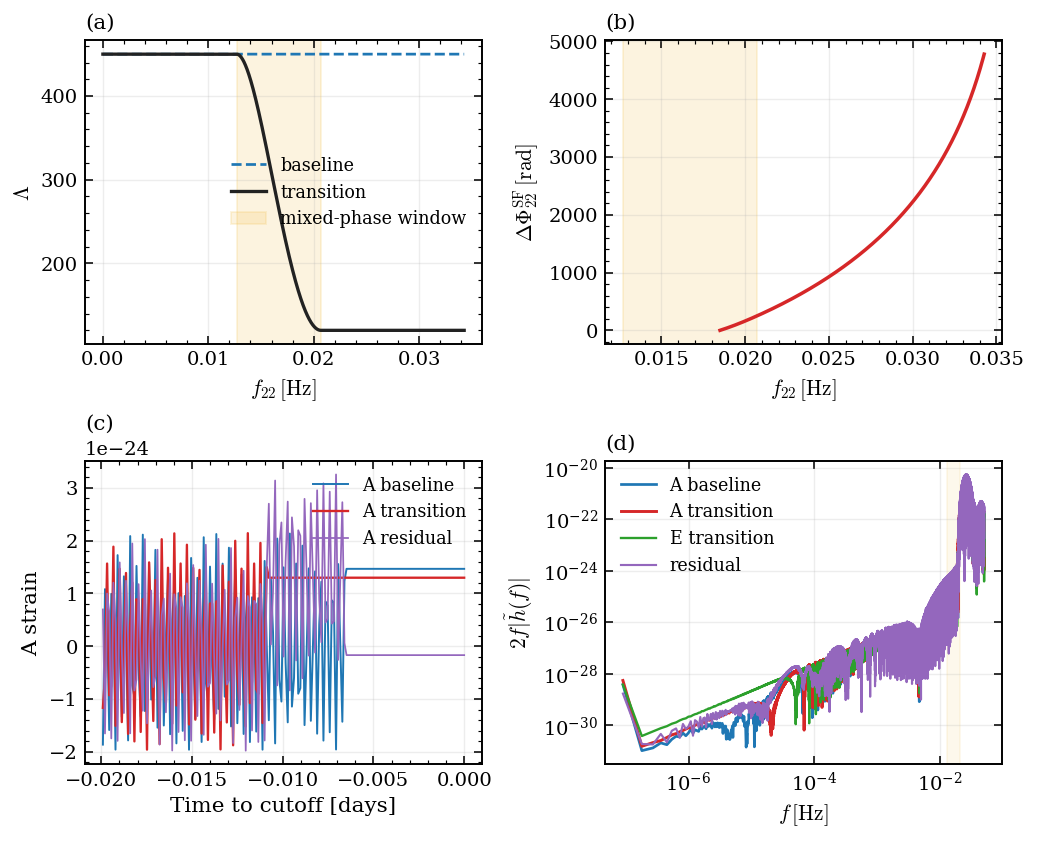

In [ ]:
# ============================================================
# Run the model with the given parameters, generate plots, and print summary

# Run the EMRI waveform model (computes baseline and transition waveforms, LISA responses)
res = run_model(pars)

# Plot the results (four-panel figure). Save if requested in parameters.
plot_results_journal(res, pars, savepath=pars["figure_name"] if pars["save_figure"] else None)

# Export data to text files if requested
if pars["save_data"]:
    export_data(res, pars)

# Print a detailed summary of the run to the console
print("=" * 72)
print("Run summary")
print("=" * 72)

# Retrieve transition band information (model type and frequency range)
band_type, f1, f2 = transition_band_in_frequency(pars)

print(f"Tobs                      = {pars['Tobs_yr']} yr")
print(f"Spin ahat                 = {pars['ahat']:+.3f}")
print(f"Transition model          = {pars['transition_model']}")
print(f"Transition freq window    = {f1:.6e} -- {f2:.6e} Hz")
print(f"Cutoff reason             = {res['cutoff_reason']}")

# If a flux root was detected, print its velocity and frequency
if res["v_root"] is not None:
    print(f"Flux zero at v_root       = {res['v_root']:.8f}")
    print(f"Flux zero at f22_root     = {f22_of_v(res['v_root'], pars):.8e} Hz")

# Termination velocity and corresponding frequency
print(f"Used v_end                = {res['v_end']:.8f}")
print(f"Used f22_end              = {f22_of_v(res['v_end'], pars):.8e} Hz")

# Starting frequencies of the observed segment for baseline and transition
print(f"Observed f22 start (base) = {res['f22_base_t'][0]:.8e} Hz")
print(f"Observed f22 start (tr)   = {res['f22_tr_t'][0]:.8e} Hz")

# Ending frequencies of the observed segment
print(f"Observed f22 end (base)   = {res['f22_base_t'][-1]:.8e} Hz")
print(f"Observed f22 end (tr)     = {res['f22_tr_t'][-1]:.8e} Hz")

# Final dephasing at the highest common frequency
print(f"Final same-freq deltaPhi  = {res['delta_phi_sf'][-1]:.6f} rad")

# Minimum Lambda values over the full grid (should be within [0,1])
print(f"Min baseline Lambda       = {np.min(res['Lambda_base_full']):.6f}")
print(f"Min transition Lambda     = {np.min(res['Lambda_tr_full']):.6f}")